# EDA


Ноутбук отвечает на практические вопросы:

1. Насколько качественны и согласованы данные?
2. Как устроены статьи и насколько сложен их HTML?
3. Насколько длинные статьи и нужны ли чанки?
4. Есть ли дубли заголовков и текстов?
5. Сколько правильных статей приходится на запрос?
6. Насколько calibration покрывает весь корпус?
7. Есть ли перекос в сторону нескольких популярных статей?
8. Насколько test похож на calibration?
9. Какие выводы EDA диктуют архитектуру retrieval-пайплайна?

## Настройка окружения и загрузка данных

In [1]:
!pip install -q pymorphy3 pymorphy3-dicts-ru

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.9/53.9 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 65.8 MB/s eta 0:00:00


In [2]:
from functools import lru_cache
from pathlib import Path
from collections import Counter
from itertools import combinations
import re
import warnings
import math
import pymorphy3

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lxml import html as lxml_html
from IPython.display import display, Markdown

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics.pairwise import linear_kernel

pd.set_option('display.max_colwidth', 140)
pd.set_option('display.max_rows', 100)

RANDOM_STATE = 42
TOP_K = 10


In [3]:
DATA_DIR = Path('/kaggle/input/datasets/naruto2009/avito-bootcamp-dataset/candidate_public/candidate_data')
articles = pd.read_feather(DATA_DIR / 'articles.f')
calibration = pd.read_feather(DATA_DIR / 'calibration.f')
test = pd.read_feather(DATA_DIR / 'test.f')

In [4]:
def dataframe_overview(df: pd.DataFrame, name: str) -> pd.DataFrame:
    return pd.DataFrame({
        'dataset': name,
        'rows': len(df),
        'columns': len(df.columns),
        'column_names': [', '.join(df.columns)],
        'missing_cells': int(df.isna().sum().sum()),
        'duplicate_rows': int(df.duplicated().sum()),
    })

overview = pd.concat([
    dataframe_overview(articles, 'articles'),
    dataframe_overview(calibration, 'calibration'),
    dataframe_overview(test, 'test'),
], ignore_index=True)
display(overview)

,dataset,rows,columns,column_names,missing_cells,duplicate_rows
0,articles,793,3,"article_id, title, body",0,0
1,calibration,500,3,"query_id, query_text, ground_truth",0,0
2,test,500,2,"query_id, query_text",0,0


### Вывод

Данные имеют небольшую размерность: менее тысячи документов и по 500 запросов в calibration/test.  
Это позволяет экспериментировать с несколькими retrieval-моделями и reranking без сложной распределённой инфраструктуры.

## Очистка HTML и инженерные признаки статей

In [5]:

def normalize_text(text: str) -> str:
    text = str(text).lower().replace('ё', 'е')
    text = re.sub(r'[^a-zа-я0-9]+', ' ', text)
    return re.sub(r'\s+', ' ', text).strip()


def parse_article_html(html: str) -> dict:
    """Быстрый разбор HTML через lxml: текст и структурные признаки за один проход."""
    raw = str(html)
    root = lxml_html.fromstring(raw)

    for bad_tag in root.xpath('//script|//style|//noscript'):
        bad_tag.drop_tree()

    clean_text = ' '.join(root.text_content().split())
    return {
        'clean_text': clean_text,
        'n_links': len(root.xpath('.//a')),
        'n_lists': len(root.xpath('.//ul|.//ol')),
        'n_list_items': len(root.xpath('.//li')),
        'n_tables': len(root.xpath('.//table')),
        'n_rows': len(root.xpath('.//tr')),
        'n_headings': len(root.xpath('.//h1|.//h2|.//h3|.//h4|.//h5|.//h6')),
        'n_images': len(root.xpath('.//img')),
        'n_buttons': len(root.xpath('.//button')),
        'n_details': len(root.xpath('.//details|.//summary')),
        'n_tags': len(root.xpath('.//*')),
    }

articles_eda = articles.copy()
parsed_html = pd.DataFrame(articles_eda['body'].map(parse_article_html).tolist())
articles_eda = pd.concat([articles_eda, parsed_html], axis=1)
articles_eda['normalized_title'] = articles_eda['title'].map(normalize_text)
articles_eda['normalized_body'] = articles_eda['clean_text'].map(normalize_text)
articles_eda['html_chars'] = articles_eda['body'].str.len()
articles_eda['text_chars'] = articles_eda['clean_text'].str.len()
articles_eda['title_chars'] = articles_eda['title'].str.len()
articles_eda['text_words'] = articles_eda['clean_text'].str.split().str.len()
articles_eda['html_to_text_ratio'] = (
    articles_eda['html_chars'] / articles_eda['text_chars'].clip(lower=1)
)

print('Признаки рассчитаны для', len(articles_eda), 'статей.')


Признаки рассчитаны для 793 статей.


## Длины статей

In [6]:
length_columns = ['title_chars', 'html_chars', 'text_chars', 'text_words', 'html_to_text_ratio']
length_stats = articles_eda[length_columns].describe(
    percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]
).T
length_stats = length_stats.rename(columns={'50%': 'median'})
display(length_stats.round(2))

,count,mean,std,min,25%,median,75%,90%,95%,99%,max
title_chars,793.0,29.216898,13.35891,5.0,20.0,28.0,37.0,45.0,52.0,65.24,113.0
html_chars,793.0,8538.161412,33793.738785,31.0,1780.0,3513.0,7887.0,18469.4,28741.4,61380.16,901357.0
text_chars,793.0,5045.145019,18287.1016,24.0,1146.0,2207.0,4696.0,10398.8,17437.8,27847.36,481930.0
text_words,793.0,650.600252,1602.088345,3.0,160.0,308.0,647.0,1386.6,2362.8,3649.08,37627.0
html_to_text_ratio,793.0,1.658922,0.558541,1.025926,1.358586,1.563336,1.816887,2.127066,2.363636,3.359024,9.04918


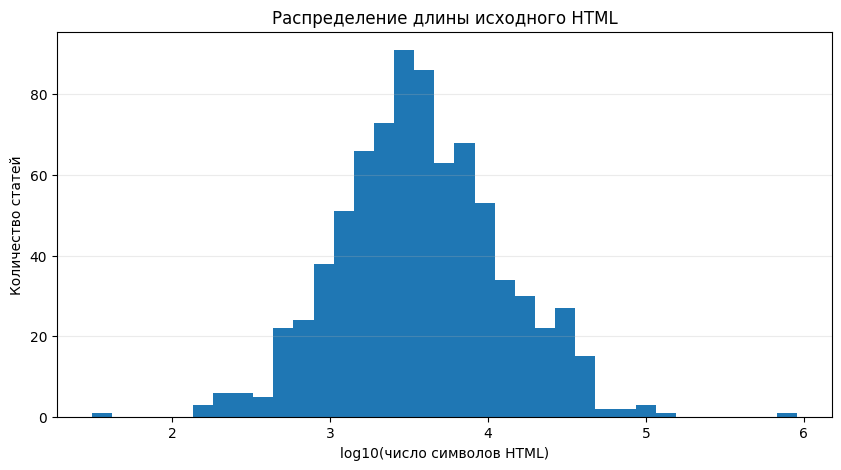

In [7]:
plt.figure(figsize=(10, 5))
plt.hist(np.log10(articles_eda['html_chars'].clip(lower=1)), bins=35)
plt.title('Распределение длины исходного HTML')
plt.xlabel('log10(число символов HTML)')
plt.ylabel('Количество статей')
plt.grid(axis='y', alpha=0.25)
plt.show()

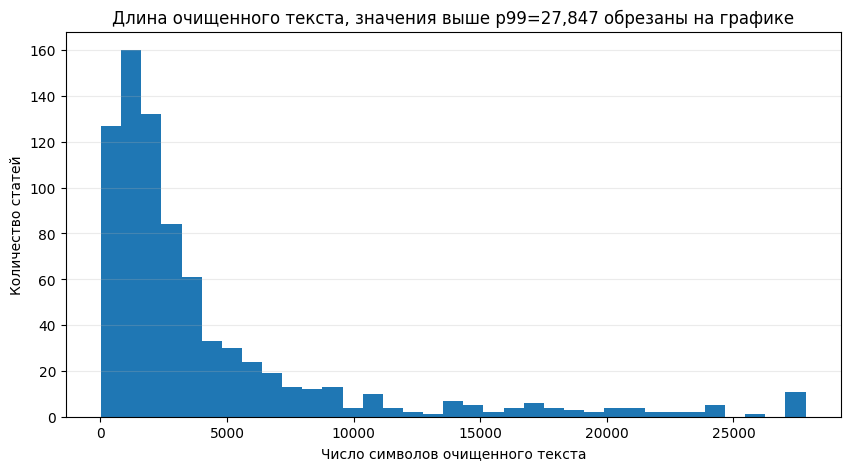

In [8]:
p99 = int(articles_eda['text_chars'].quantile(0.99))
plt.figure(figsize=(10, 5))
plt.hist(articles_eda['text_chars'].clip(upper=p99), bins=35)
plt.title(f'Длина очищенного текста, значения выше p99={p99:,} обрезаны на графике')
plt.xlabel('Число символов очищенного текста')
plt.ylabel('Количество статей')
plt.grid(axis='y', alpha=0.25)
plt.show()

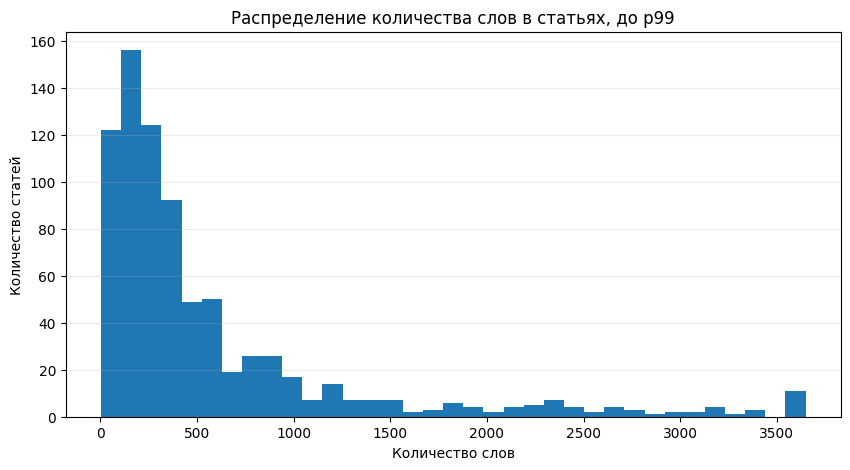

In [9]:
plt.figure(figsize=(10, 5))
plt.hist(articles_eda['text_words'].clip(upper=articles_eda['text_words'].quantile(0.99)), bins=35)
plt.title('Распределение количества слов в статьях, до p99')
plt.xlabel('Количество слов')
plt.ylabel('Количество статей')
plt.grid(axis='y', alpha=0.25)
plt.show()

In [10]:
longest_articles = articles_eda.nlargest(15, 'text_chars')[
    ['article_id', 'title', 'html_chars', 'text_chars', 'text_words', 'n_tags']
]
display(longest_articles)

,article_id,title,html_chars,text_chars,text_words,n_tags
245,2924,Какими товарами интересуются покупатели,901357,481930,37627,49157
730,4436,Уровень сервиса,116805,76814,10334,2199
620,4321,Мой уровень сервиса,115336,75318,10109,2190
527,4220,Объявление о транспорте,90218,49923,6703,1592
572,4266,Недвижимость,70287,49793,6958,850
549,4243,"Вещи, техника и другие товары",102707,48584,5435,2737
540,4234,Как продавать и покупать с доставкой,64825,34610,4867,1219
548,4242,"Как указать параметры, чтобы объявления соединились",61308,28346,2501,3502
563,4257,Как работать с Защитой сделки: информация для исполнителей,40577,27804,3903,549
606,4307,Лимит бесплатных размещений,62210,27359,3624,1565


### Интерпретация

Распределение длин имеет тяжёлый правый хвост: небольшое число статей намного длиннее основной массы.  
Использование полного документа как единого passage приводит к двум рискам:

- релевантный фрагмент размывается нерелевантным контекстом;
- нейросетевые модели вынуждены обрезать текст по максимальной длине.

Следовательно, для retrieval оправдано разбиение статей на смысловые чанки с последующей агрегацией скора на уровне id.

## Структура и сложность HTML

In [11]:
html_columns = [
    'n_tags', 'n_links', 'n_lists', 'n_list_items', 'n_tables',
    'n_rows', 'n_headings', 'n_images', 'n_buttons', 'n_details'
]
html_stats = articles_eda[html_columns].describe(
    percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]
).T
display(html_stats.round(2))

,count,mean,std,min,50%,75%,90%,95%,99%,max
n_tags,793.0,198.19,1759.94,0.0,57.0,137.0,346.2,534.4,1230.44,49157.0
n_links,793.0,8.53,16.69,0.0,4.0,9.0,20.8,34.0,62.56,313.0
n_lists,793.0,5.07,13.79,0.0,2.0,5.0,11.8,19.0,35.48,287.0
n_list_items,793.0,46.81,854.71,0.0,6.0,16.0,38.8,58.0,146.96,24047.0
n_tables,793.0,0.21,1.04,0.0,0.0,0.0,0.0,1.0,4.00,20.0
n_rows,793.0,1.60,12.92,0.0,0.0,0.0,0.0,4.0,27.08,276.0
n_headings,793.0,3.85,6.44,0.0,2.0,5.0,10.0,16.0,30.08,56.0
n_images,793.0,2.15,4.42,0.0,0.0,2.0,7.0,11.0,21.00,47.0
n_buttons,793.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.0
n_details,793.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.0


In [12]:
feature_presence = pd.DataFrame({
    'HTML-элемент': html_columns[1:],
    'Статей с элементом': [(articles_eda[col] > 0).sum() for col in html_columns[1:]],
})
feature_presence['Доля статей, %'] = (
    feature_presence['Статей с элементом'] / len(articles_eda) * 100
).round(1)
display(feature_presence.sort_values('Доля статей, %', ascending=False))

,HTML-элемент,Статей с элементом,"Доля статей, %"
0,n_links,687,86.6
2,n_list_items,598,75.4
1,n_lists,591,74.5
5,n_headings,477,60.2
6,n_images,373,47.0
4,n_rows,68,8.6
3,n_tables,67,8.4
7,n_buttons,0,0.0
8,n_details,0,0.0


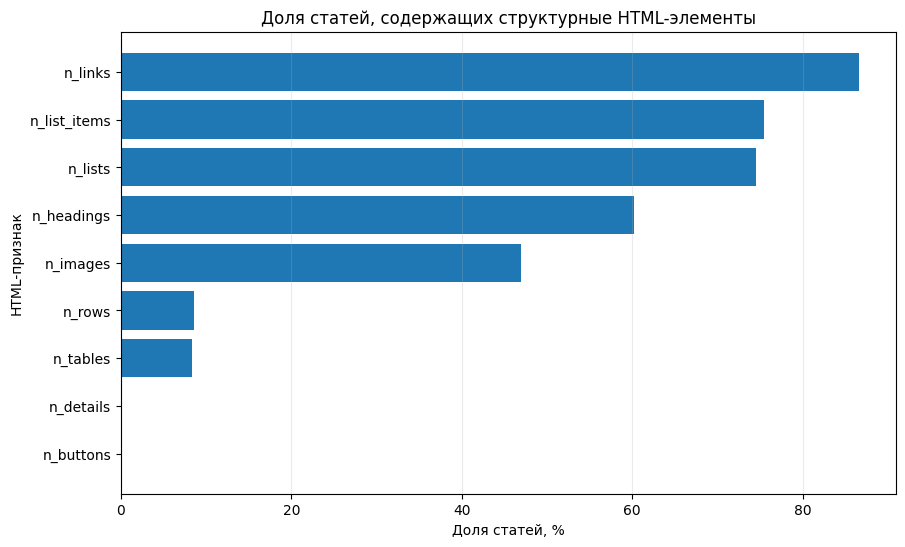

In [13]:
plot_data = feature_presence.sort_values('Доля статей, %', ascending=True)
plt.figure(figsize=(10, 6))
plt.barh(plot_data['HTML-элемент'], plot_data['Доля статей, %'])
plt.title('Доля статей, содержащих структурные HTML-элементы')
plt.xlabel('Доля статей, %')
plt.ylabel('HTML-признак')
plt.grid(axis='x', alpha=0.25)
plt.show()

In [14]:
complex_articles = articles_eda.nlargest(12, 'n_tags')[
    ['article_id', 'title', 'n_tags', 'n_links', 'n_list_items', 'n_tables', 'n_rows', 'n_headings']
]
display(complex_articles)

,article_id,title,n_tags,n_links,n_list_items,n_tables,n_rows,n_headings
245,2924,Какими товарами интересуются покупатели,49157,0,24047,0,0,0
548,4242,"Как указать параметры, чтобы объявления соединились",3502,0,1004,20,162,15
549,4243,"Вещи, техника и другие товары",2737,313,55,7,276,25
730,4436,Уровень сервиса,2199,80,378,8,24,55
620,4321,Мой уровень сервиса,2190,80,372,8,24,54
527,4220,Объявление о транспорте,1592,69,242,0,0,27
606,4307,Лимит бесплатных размещений,1565,46,72,1,3,56
627,4328,Что можно заказать и отправить,1362,37,394,1,11,11
540,4234,Как продавать и покупать с доставкой,1219,126,74,4,20,19
772,4519,Профессиональный план в Услугах,1088,36,98,3,72,19


### Интерпретация

Текст нельзя очищать простым удалением всего между <...>: таблицы, списки и заголовки содержат полезную структуру.  
Оптимальная подготовка документа должна сохранять текст ячеек, пунктов и заголовков разделов, а служебные теги удалять.

## Дубли и близкие документы

In [15]:
title_counts = articles_eda['normalized_title'].value_counts()
duplicate_title_groups = title_counts[title_counts > 1]

n_extra_duplicate_title_rows = int((duplicate_title_groups - 1).sum())
n_duplicate_title_groups = int(len(duplicate_title_groups))
n_articles_in_duplicate_groups = int(duplicate_title_groups.sum())

body_counts = articles_eda['normalized_body'].value_counts()
duplicate_body_groups = body_counts[body_counts > 1]

summary_duplicates = pd.DataFrame({
    'Метрика': [
        'Групп совпадающих нормализованных заголовков',
        'Статей в группах совпадающих заголовков',
        'Повторных строк заголовков сверх первой',
        'Групп полностью совпадающих очищенных текстов',
        'Статей в группах совпадающих очищенных текстов',
    ],
    'Значение': [
        n_duplicate_title_groups,
        n_articles_in_duplicate_groups,
        n_extra_duplicate_title_rows,
        len(duplicate_body_groups),
        int(duplicate_body_groups.sum()),
    ]
})
display(summary_duplicates)

,Метрика,Значение
0,Групп совпадающих нормализованных заголовков,82
1,Статей в группах совпадающих заголовков,175
2,Повторных строк заголовков сверх первой,93
3,Групп полностью совпадающих очищенных текстов,36
4,Статей в группах совпадающих очищенных текстов,72


In [16]:
duplicate_title_examples = (
    articles_eda[articles_eda['normalized_title'].isin(duplicate_title_groups.index)]
    .sort_values(['normalized_title', 'article_id'])
    [['article_id', 'title', 'text_chars', 'normalized_title']]
)
display(duplicate_title_examples.head(40))

,article_id,title,text_chars,normalized_title
544,4238,API для бизнеса,4539,api для бизнеса
642,4343,API для бизнеса,4539,api для бизнеса
95,2148,XL-объявление,2842,xl объявление
438,3909,XL-объявление,2842,xl объявление
554,4248,Авито Бизнес 360,7483,авито бизнес 360
600,4299,Авито Бизнес 360,7502,авито бизнес 360
790,4548,Автоматический чат с продавцом,3702,автоматический чат с продавцом
791,4549,Автоматический чат с продавцом,3412,автоматический чат с продавцом
698,4402,Автоответы,6796,автоответы
709,4413,Автоответы,6875,автоответы


In [17]:
if len(duplicate_body_groups):
    duplicate_body_examples = (
        articles_eda[articles_eda['normalized_body'].isin(duplicate_body_groups.index)]
        .sort_values(['normalized_body', 'article_id'])
        [['article_id', 'title', 'text_chars']]
    )
    display(duplicate_body_examples.head(30))
else:
    print('Полных дублей очищенного текста не найдено.')

,article_id,title,text_chars
95,2148,XL-объявление,2842
438,3909,XL-объявление,2842
98,2152,Как работают несколько услуг одновременно,2640
465,4081,Как работают несколько услуг одновременно,2638
771,4518,"Тариф с оплатой за просмотры в категориях «Электроника», «Хобби и отдых», «Личные вещи» и «Запчасти и аксессуары»",1934
783,4530,"Тариф с оплатой за просмотры: «Электроника», «Хобби и отдых», «Личные вещи» и «Запчасти и аксессуары»",1934
331,3481,Контакты арендодателя платные,4309
332,3482,Почему контакты арендодателя платные,4309
433,3888,Ассистент для продавцов и покупателей,2274
436,3895,Ассистент для продавцов и покупателей,2274


### Интерпретация

Совпадение заголовка не означает совпадение документа: одинаково названные статьи могут относиться к разным сценариям или содержать разные инструкции.  
Поэтому поиск только по `title` недостаточен. Заголовок следует использовать как усиленный признак, но ранжирование должно учитывать тело и релевантный раздел статьи.

## 7. Оценка размера chunk-индекса

In [18]:
def estimated_chunk_count(length: int, chunk_size: int = 1000, overlap: int = 200) -> int:
    if length <= chunk_size:
        return 1
    step = chunk_size - overlap
    return 1 + math.ceil((length - chunk_size) / step)

articles_eda['estimated_chunks'] = articles_eda['text_chars'].map(estimated_chunk_count)
chunk_stats = articles_eda['estimated_chunks'].describe(
    percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]
).to_frame('estimated_chunks')
display(chunk_stats)
print('Всего ожидаемых чанков:', int(articles_eda['estimated_chunks'].sum()))
print('Среднее чанков на статью:', round(articles_eda['estimated_chunks'].mean(), 2))

,estimated_chunks
count,793.000000
mean,6.588903
std,22.862401
min,1.000000
50%,3.000000
75%,6.000000
90%,13.000000
95%,22.000000
99%,35.080000
max,603.000000


Всего ожидаемых чанков: 5225
Среднее чанков на статью: 6.59


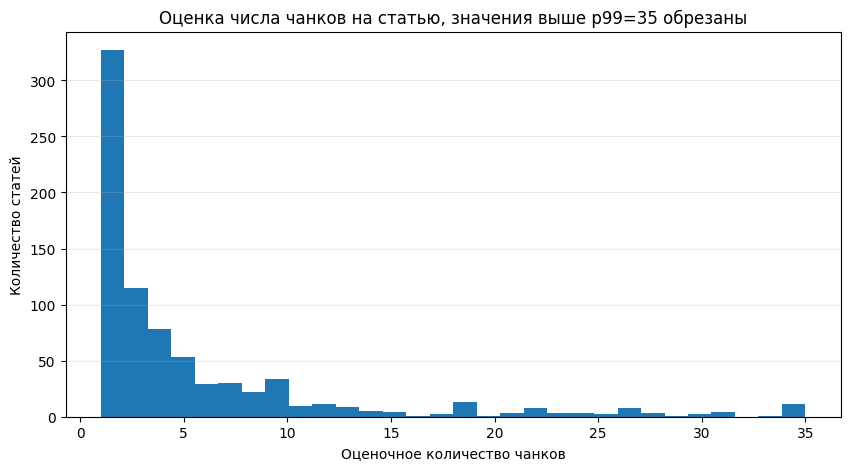

In [19]:
chunk_cap = int(articles_eda['estimated_chunks'].quantile(0.99))
plt.figure(figsize=(10, 5))
plt.hist(articles_eda['estimated_chunks'].clip(upper=chunk_cap), bins=30)
plt.title(f'Оценка числа чанков на статью, значения выше p99={chunk_cap} обрезаны')
plt.xlabel('Оценочное количество чанков')
plt.ylabel('Количество статей')
plt.grid(axis='y', alpha=0.25)
plt.show()

## Анализ пользовательских запросов

In [20]:
POLITE_PATTERN = re.compile(
    r'^(здравствуйте|добрый день|добрый вечер|привет|подскажите|скажите|пожалуйста|'
    r'можете подсказать|хотелось бы узнать)[,!\.\s-]*',
    flags=re.IGNORECASE
)

def add_query_features(df: pd.DataFrame) -> pd.DataFrame:
    result = df.copy()
    result['normalized_query'] = result['query_text'].map(normalize_text)
    result['query_chars'] = result['query_text'].str.len()
    result['query_words'] = result['normalized_query'].str.split().str.len()
    result['has_question_mark'] = result['query_text'].str.contains(r'\?', regex=True)
    result['has_digits'] = result['query_text'].str.contains(r'\d', regex=True)
    result['starts_polite'] = result['query_text'].str.contains(POLITE_PATTERN, regex=True)
    return result

cal_eda = add_query_features(calibration)
test_eda = add_query_features(test)

/tmp/ipykernel_16/829420220.py:14: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  result['starts_polite'] = result['query_text'].str.contains(POLITE_PATTERN, regex=True)
/tmp/ipykernel_16/829420220.py:14: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  result['starts_polite'] = result['query_text'].str.contains(POLITE_PATTERN, regex=True)


In [21]:
def query_stats(df: pd.DataFrame, name: str) -> pd.Series:
    return pd.Series({
        'dataset': name,
        'queries': len(df),
        'mean_chars': df['query_chars'].mean(),
        'median_chars': df['query_chars'].median(),
        'p90_chars': df['query_chars'].quantile(0.9),
        'mean_words': df['query_words'].mean(),
        'median_words': df['query_words'].median(),
        'with_question_mark_%': df['has_question_mark'].mean() * 100,
        'with_digits_%': df['has_digits'].mean() * 100,
        'polite_opening_%': df['starts_polite'].mean() * 100,
        'unique_normalized_%': df['normalized_query'].nunique() / len(df) * 100,
    })

query_summary = pd.DataFrame([
    query_stats(cal_eda, 'calibration'),
    query_stats(test_eda, 'test'),
]).set_index('dataset')
display(query_summary.round(2))

,queries,mean_chars,median_chars,p90_chars,mean_words,median_words,with_question_mark_%,with_digits_%,polite_opening_%,unique_normalized_%
dataset,,,,,,,,,,
calibration,500,76.25,69.0,128.0,11.57,10.0,54.2,11.0,39.0,99.6
test,500,76.44,66.0,139.0,11.77,10.0,50.8,11.6,38.6,99.8


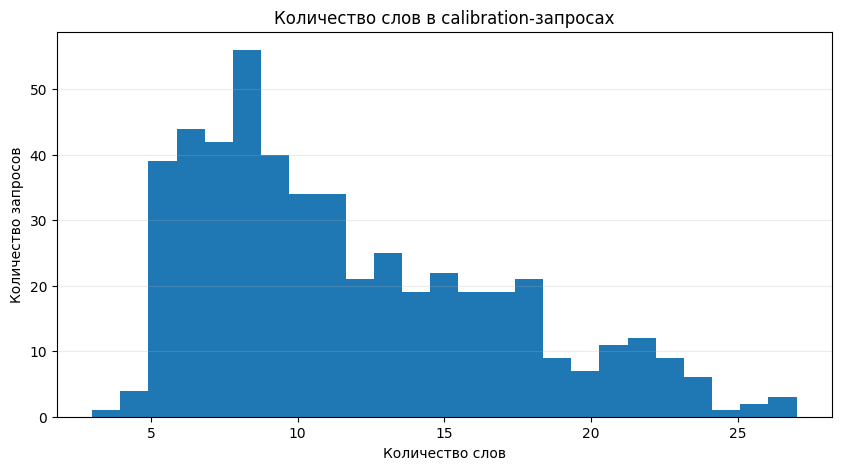

In [22]:
plt.figure(figsize=(10, 5))
plt.hist(cal_eda['query_words'], bins=25)
plt.title('Количество слов в calibration-запросах')
plt.xlabel('Количество слов')
plt.ylabel('Количество запросов')
plt.grid(axis='y', alpha=0.25)
plt.show()

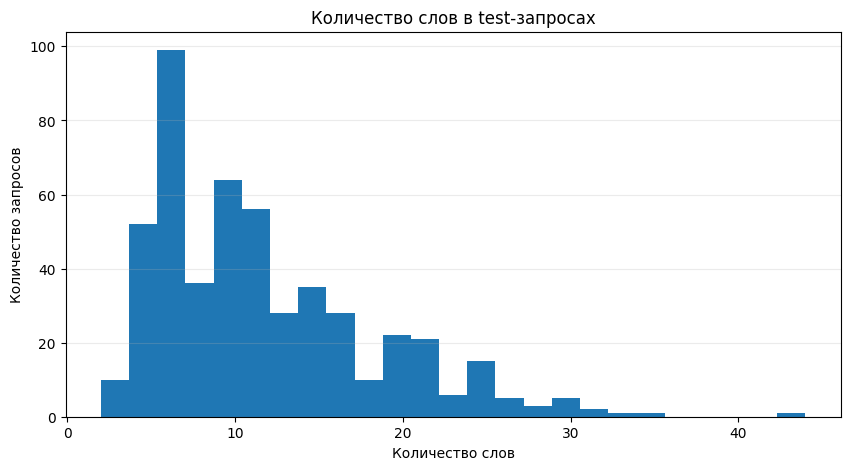

In [23]:
plt.figure(figsize=(10, 5))
plt.hist(test_eda['query_words'], bins=25)
plt.title('Количество слов в test-запросах')
plt.xlabel('Количество слов')
plt.ylabel('Количество запросов')
plt.grid(axis='y', alpha=0.25)
plt.show()

In [24]:
within_cal_duplicates = cal_eda['normalized_query'].duplicated(keep=False).sum()
within_test_duplicates = test_eda['normalized_query'].duplicated(keep=False).sum()
cal_queries_set = set(cal_eda['normalized_query'])
test_queries_set = set(test_eda['normalized_query'])
exact_cross_duplicates = sorted(cal_queries_set & test_queries_set)

query_duplicate_summary = pd.DataFrame({
    'Метрика': [
        'Строк calibration, участвующих во внутренних дублях',
        'Строк test, участвующих во внутренних дублях',
        'Точных нормализованных совпадений между calibration и test',
    ],
    'Значение': [within_cal_duplicates, within_test_duplicates, len(exact_cross_duplicates)]
})
display(query_duplicate_summary)

if exact_cross_duplicates:
    print('Примеры точных совпадений:')
    display(pd.DataFrame({'normalized_query': exact_cross_duplicates[:20]}))

,Метрика,Значение
0,"Строк calibration, участвующих во внутренних дублях",4
1,"Строк test, участвующих во внутренних дублях",2
2,Точных нормализованных совпадений между calibration и test,1


Примеры точных совпадений:


,normalized_query
0,когда мне вернут деньги за возврат


## Частотные слова и формулировки

In [25]:
RUSSIAN_STOPWORDS = {
    'и','в','во','не','что','он','на','я','с','со','как','а','то','все','она',
    'так','его','но','да','ты','к','у','же','вы','за','бы','по','только','ее',
    'мне','было','вот','от','меня','еще','нет','о','из','ему','теперь','когда',
    'даже','ну','ли','если','или','ни','быть','был','него','до','вас','нибудь',
    'опять','уж','вам','ведь','там','потом','себя','ничего','ей','может','они',
    'тут','где','есть','надо','ней','для','мы','тебя','их','чем','была','сам',
    'чтоб','без','будто','чего','раз','тоже','себе','под','будет','ж','тогда',
    'кто','этот','того','потому','этого','какой','совсем','ним','здесь','этом',
    'один','почти','мой','тем','чтобы','нее','сейчас','были','куда','зачем',
    'сказать','всех','никогда','сегодня','можно','при','наконец','два','об',
    'другой','хоть','после','над','больше','тот','через','эти','нас','про',
    'всего','них','какая','много','разве','три','эту','моя','впрочем','хорошо',
    'свою','этой','перед','иногда','лучше','чуть','том','нельзя','такой','им',
    'более','всегда','конечно','всю','между',

    'здравствуйте','подскажите','пожалуйста','скажите','привет','добрый',
    'день','вечер','можете'
}


morph = pymorphy3.MorphAnalyzer()


def lemmatize_token(token: str) -> str:

    token = token.lower().replace('ё', 'е')

    if token.isdigit():
        return token

    if not token.isalpha():
        return token

    # Не пропускаем через русский морфологический анализатор
    # латинские названия: avito, cdek, boxberry и т. п.
    if not any('а' <= char <= 'я' for char in token):
        return token

    return morph.parse(token)[0].normal_form


def lemmatize_text(text: str) -> str:
    
    tokens = str(text).split()
    return ' '.join(lemmatize_token(token) for token in tokens)


# Лемматизируем сами стоп-слова, чтобы удалялись их нормальные формы.
LEMMATIZED_STOPWORDS = {
    lemmatize_token(word)
    for word in RUSSIAN_STOPWORDS
}


# Создаём отдельные колонки, чтобы исходный нормализованный текст сохранился.
cal_eda['lemmatized_query'] = (
    cal_eda['normalized_query']
    .fillna('')
    .map(lemmatize_text)
)

test_eda['lemmatized_query'] = (
    test_eda['normalized_query']
    .fillna('')
    .map(lemmatize_text)
)


def top_terms(
    texts,
    ngram_range=(1, 1),
    top_n=20,
    min_df=2,
):
    vectorizer = CountVectorizer(
        lowercase=False,  # тексты уже приведены к нижнему регистру
        ngram_range=ngram_range,
        stop_words=list(LEMMATIZED_STOPWORDS),
        min_df=min_df,
        token_pattern=r'(?u)\b[а-яa-z0-9]{2,}\b',
    )

    matrix = vectorizer.fit_transform(texts)

    counts = np.asarray(matrix.sum(axis=0)).ravel()
    terms = np.asarray(vectorizer.get_feature_names_out())

    order = np.argsort(counts)[::-1][:top_n]

    return pd.DataFrame({
        'term': terms[order],
        'count': counts[order],
    })


cal_top_terms = top_terms(
    cal_eda['lemmatized_query'],
    ngram_range=(1, 2),
    top_n=20,
)

test_top_terms = top_terms(
    test_eda['lemmatized_query'],
    ngram_range=(1, 2),
    top_n=20,
)


print('Calibration:')
display(cal_top_terms)

print('Test:')
display(test_top_terms)

Calibration:


,term,count
0,доставка,224
1,деньга,145
2,товар,121
3,заказ,111
4,авить,106
5,почему,102
6,авить доставка,65
7,объявление,62
8,оплатить,58
9,отправить,56


Test:


,term,count
0,доставка,187
1,деньга,178
2,товар,141
3,заказ,132
4,авить,100
5,почему,99
6,вернуть,67
7,объявление,57
8,оплатить,50
9,авить доставка,50


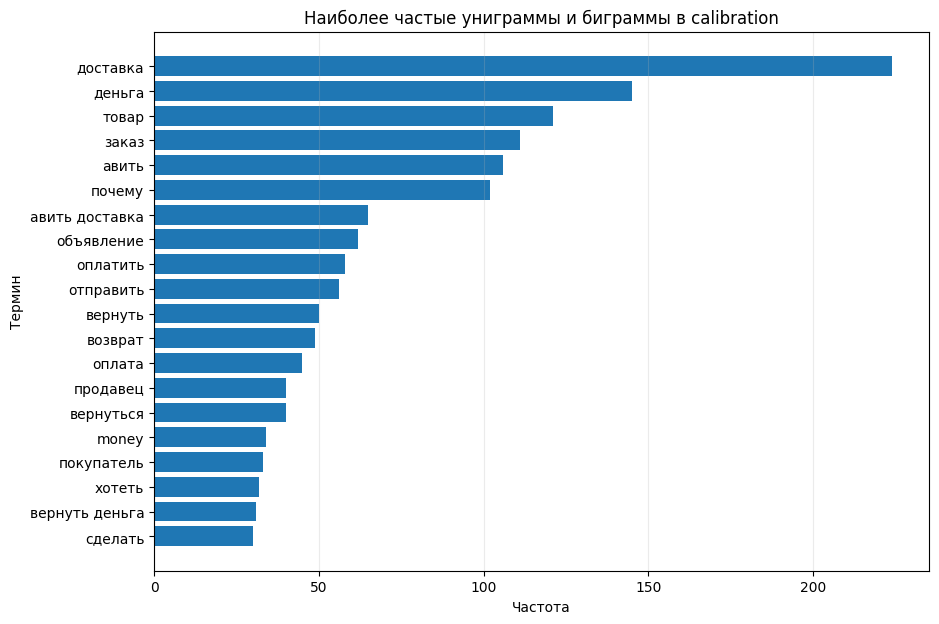

In [26]:
plot_terms = cal_top_terms.sort_values('count')
plt.figure(figsize=(10, 7))
plt.barh(plot_terms['term'], plot_terms['count'])
plt.title('Наиболее частые униграммы и биграммы в calibration')
plt.xlabel('Частота')
plt.ylabel('Термин')
plt.grid(axis='x', alpha=0.25)
plt.show()

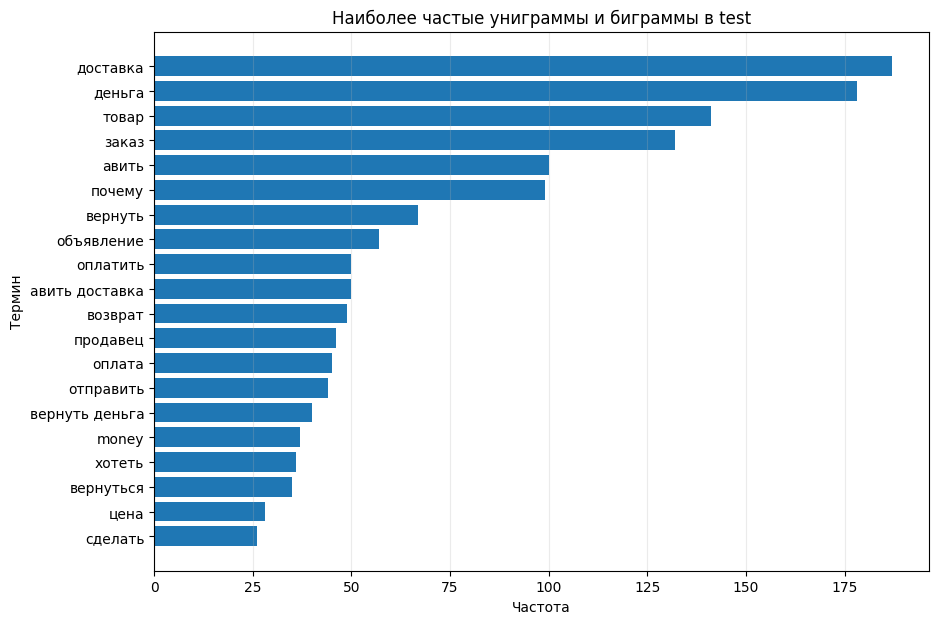

In [27]:
plot_terms = test_top_terms.sort_values('count')
plt.figure(figsize=(10, 7))
plt.barh(plot_terms['term'], plot_terms['count'])
plt.title('Наиболее частые униграммы и биграммы в test')
plt.xlabel('Частота')
plt.ylabel('Термин')
plt.grid(axis='x', alpha=0.25)
plt.show()

### Интерпретация

Запросы короткие, разговорные и часто содержат вводные фразы, опечатки и различные словоформы.  
Это аргумент в пользу символьных n-грамм: они устойчивее к ошибкам и морфологическим вариациям, чем точное совпадение слов.

## Анализ multilabel-разметки

In [28]:
def parse_ground_truth(value: str) -> list[int]:
    return [int(x) for x in str(value).split() if x.strip()]

cal_eda['relevant_ids'] = cal_eda['ground_truth'].map(parse_ground_truth)
cal_eda['n_relevant'] = cal_eda['relevant_ids'].str.len()

article_id_set = set(articles_eda['article_id'])

In [29]:
relevant_count_table = (
    cal_eda['n_relevant']
    .value_counts()
    .sort_index()
    .rename_axis('Количество релевантных статей')
    .to_frame('Количество запросов')
)
relevant_count_table['Доля запросов, %'] = (
    relevant_count_table['Количество запросов'] / len(cal_eda) * 100
).round(1)
display(relevant_count_table)

print('Среднее релевантных статей:', round(cal_eda['n_relevant'].mean(), 3))
print('Медиана:', int(cal_eda['n_relevant'].median()))
print('Запросов с несколькими релевантными статьями:', int((cal_eda['n_relevant'] > 1).sum()))

,Количество запросов,"Доля запросов, %"
Количество релевантных статей,,
1,279,55.8
2,182,36.4
3,38,7.6
4,1,0.2


Среднее релевантных статей: 1.522
Медиана: 1
Запросов с несколькими релевантными статьями: 221


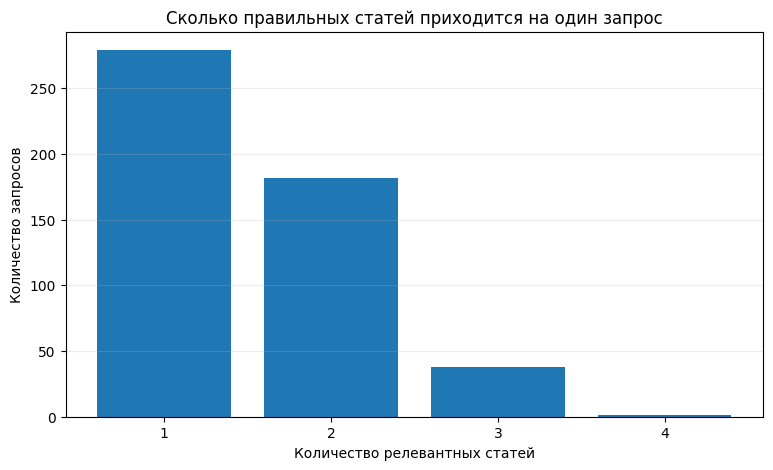

In [30]:
count_plot = relevant_count_table.reset_index()
plt.figure(figsize=(9, 5))
plt.bar(
    count_plot['Количество релевантных статей'].astype(str),
    count_plot['Количество запросов']
)
plt.title('Сколько правильных статей приходится на один запрос')
plt.xlabel('Количество релевантных статей')
plt.ylabel('Количество запросов')
plt.grid(axis='y', alpha=0.25)
plt.show()

### Интерпретация

Задача действительно multilabel: для существенной доли запросов правильных документов несколько.  
Оптимизация только top-1 accuracy не соответствует целевой метрике. Нужно ранжировать все релевантные статьи как можно выше в top-10.

## Покрытие корпуса и частотность релевантных статей

In [31]:
label_counter = Counter(article_id for ids in cal_eda['relevant_ids'] for article_id in ids)
label_frequency = pd.DataFrame(
    label_counter.items(), columns=['article_id', 'label_frequency']
).merge(articles_eda[['article_id', 'title']], on='article_id', how='left')
label_frequency = label_frequency.sort_values('label_frequency', ascending=False).reset_index(drop=True)

unique_relevant_articles = len(label_frequency)
coverage_pct = unique_relevant_articles / len(articles_eda) * 100
singletons = int((label_frequency['label_frequency'] == 1).sum())

total_label_occurrences = int(label_frequency['label_frequency'].sum())
top_10_share = (
    label_frequency.head(10)['label_frequency'].sum() / total_label_occurrences * 100
)

coverage_summary = pd.DataFrame({
    'Метрика': [
        'Уникальных статей в calibration ground_truth',
        'Всего статей в корпусе',
        'Покрытие корпуса разметкой, %',
        'Статей, встречающихся ровно один раз',
        'Максимальная частота одной статьи',
        'Доля top-10 статей во всех label occurrence, %',
    ],
    'Значение': [
        unique_relevant_articles,
        len(articles_eda),
        round(coverage_pct, 2),
        singletons,
        int(label_frequency['label_frequency'].max()),
        round(top_10_share, 2),
    ]
})
display(coverage_summary)

,Метрика,Значение
0,Уникальных статей в calibration ground_truth,79.00
1,Всего статей в корпусе,793.00
2,"Покрытие корпуса разметкой, %",9.96
3,"Статей, встречающихся ровно один раз",40.00
4,Максимальная частота одной статьи,129.00
5,"Доля top-10 статей во всех label occurrence, %",65.44


In [32]:
display(label_frequency.head(25))

,article_id,label_frequency,title
0,4219,129,Покупателю
1,1951,73,Кто оплачивает доставку и сколько она стоит
2,4234,63,Как продавать и покупать с доставкой
3,2646,57,Оплата заказов с доставкой
4,4328,39,Что можно заказать и отправить
5,4400,33,Покупателю — отказаться от товара или вернуть его
6,4214,31,"Скидки, бонусы и промокоды"
7,4384,26,Баланс для покупок
8,4440,26,"Платёж прошёл, но есть проблема"
9,4387,21,Всё про отмену заказа


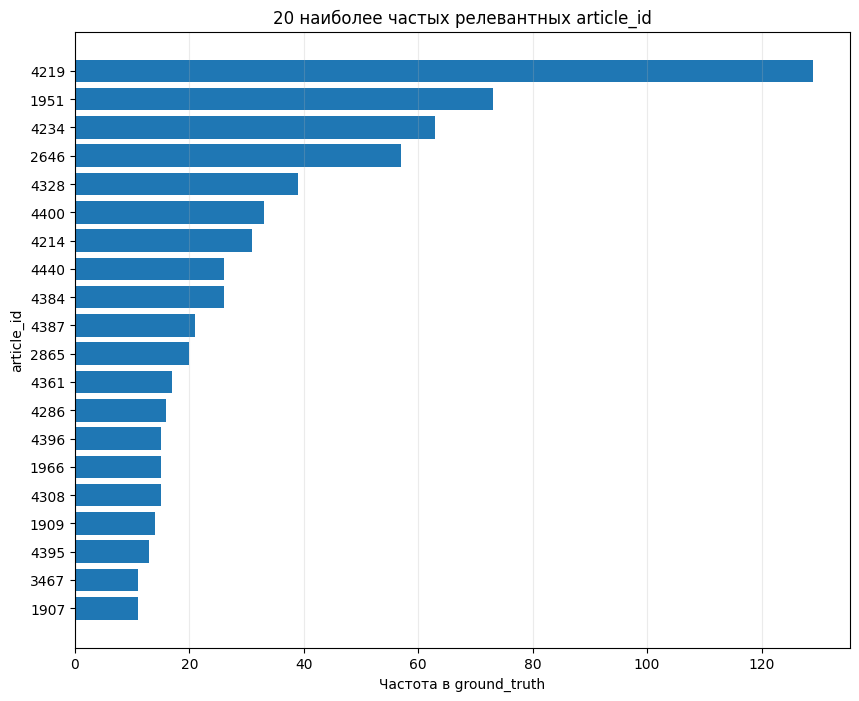

In [33]:
top_labels = label_frequency.head(20).sort_values('label_frequency')
plt.figure(figsize=(10, 8))
plt.barh(top_labels['article_id'].astype(str), top_labels['label_frequency'])
plt.title('20 наиболее частых релевантных article_id')
plt.xlabel('Частота в ground_truth')
plt.ylabel('article_id')
plt.grid(axis='x', alpha=0.25)
plt.show()

In [34]:
frequency_distribution = (
    label_frequency['label_frequency']
    .value_counts()
    .sort_index()
    .rename_axis('Частота статьи в ground_truth')
    .to_frame('Количество article_id')
)
display(frequency_distribution.head(25))

,Количество article_id
Частота статьи в ground_truth,
1,40
2,12
4,1
5,1
8,3
9,1
10,1
11,2
13,1


In [35]:
def gini(values) -> float:
    x = np.asarray(values, dtype=float)
    if len(x) == 0 or np.all(x == 0):
        return 0.0
    x = np.sort(x)
    n = len(x)
    cumulative = np.cumsum(x)
    return float((n + 1 - 2 * cumulative.sum() / cumulative[-1]) / n)

print('Gini по частотам размеченных статей:', round(gini(label_frequency['label_frequency']), 3))

Gini по частотам размеченных статей: 0.728


### Интерпретация

Разметка покрывает лишь небольшую часть корпуса и сильно несбалансирована.  
Поэтому перенос меток от похожих calibration-запросов может быть очень эффективен для популярных сценариев, но нельзя ограничивать candidate set только известными  `article_id`: test может содержать сценарии, отсутствующие в calibration.

## Совместно релевантные статьи

In [36]:
pair_counter = Counter()
for ids in cal_eda['relevant_ids']:
    for pair in combinations(sorted(set(ids)), 2):
        pair_counter[pair] += 1

pair_rows = []
title_lookup = articles_eda.set_index('article_id')['title'].to_dict()
for (left_id, right_id), frequency in pair_counter.most_common(20):
    pair_rows.append({
        'article_id_1': left_id,
        'title_1': title_lookup.get(left_id),
        'article_id_2': right_id,
        'title_2': title_lookup.get(right_id),
        'cooccurrence': frequency,
    })
cooccurrence_df = pd.DataFrame(pair_rows)
display(cooccurrence_df)

,article_id_1,title_1,article_id_2,title_2,cooccurrence
0,2646,Оплата заказов с доставкой,4219,Покупателю,45
1,4219,Покупателю,4384,Баланс для покупок,15
2,2865,Когда вернутся деньги за доставку,4219,Покупателю,14
3,1951,Кто оплачивает доставку и сколько она стоит,4234,Как продавать и покупать с доставкой,13
4,1966,Когда вернутся деньги после отмены доставки в пункт выдачи,4219,Покупателю,11
5,4286,Грузовая доставка,4328,Что можно заказать и отправить,11
6,4219,Покупателю,4400,Покупателю — отказаться от товара или вернуть его,9
7,4328,Что можно заказать и отправить,4396,Не могу отправить заказ,8
8,1951,Кто оплачивает доставку и сколько она стоит,3467,Как создать и настроить тарифы,7
9,2646,Оплата заказов с доставкой,2865,Когда вернутся деньги за доставку,7


### Интерпретация

Повторяющиеся пары показывают, что документы могут быть комплементарными: например, одна статья описывает общий процесс, а другая — конкретный способ доставки или возврата.  
Эту структуру можно использовать как слабый сигнал при post-processing или learning-to-rank.

## Сходство test и calibration

In [37]:
query_vectorizer = TfidfVectorizer(
    analyzer='char_wb',
    ngram_range=(3, 5),
    min_df=1,
    max_features=100_000,
    sublinear_tf=True,
)
all_queries = pd.concat([
    cal_eda['normalized_query'],
    test_eda['normalized_query'],
], ignore_index=True)
all_matrix = query_vectorizer.fit_transform(all_queries)
cal_matrix = all_matrix[:len(cal_eda)]
test_matrix = all_matrix[len(cal_eda):]

similarity_matrix = linear_kernel(test_matrix, cal_matrix)
nearest_cal_index = similarity_matrix.argmax(axis=1)
nearest_cal_similarity = similarity_matrix.max(axis=1)

test_similarity = test_eda[['query_id', 'query_text']].copy()
test_similarity['nearest_cal_index'] = nearest_cal_index
test_similarity['nearest_similarity'] = nearest_cal_similarity
test_similarity['nearest_cal_query_id'] = cal_eda.iloc[nearest_cal_index]['query_id'].to_numpy()
test_similarity['nearest_cal_query'] = cal_eda.iloc[nearest_cal_index]['query_text'].to_numpy()
test_similarity['nearest_ground_truth'] = cal_eda.iloc[nearest_cal_index]['ground_truth'].to_numpy()

similarity_quantiles = test_similarity['nearest_similarity'].describe(
    percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]
).to_frame('nearest_similarity')
display(similarity_quantiles)

,nearest_similarity
count,500.000000
mean,0.408260
std,0.148908
min,0.138327
10%,0.241379
25%,0.299665
50%,0.381191
75%,0.502192
90%,0.592562
95%,0.684514


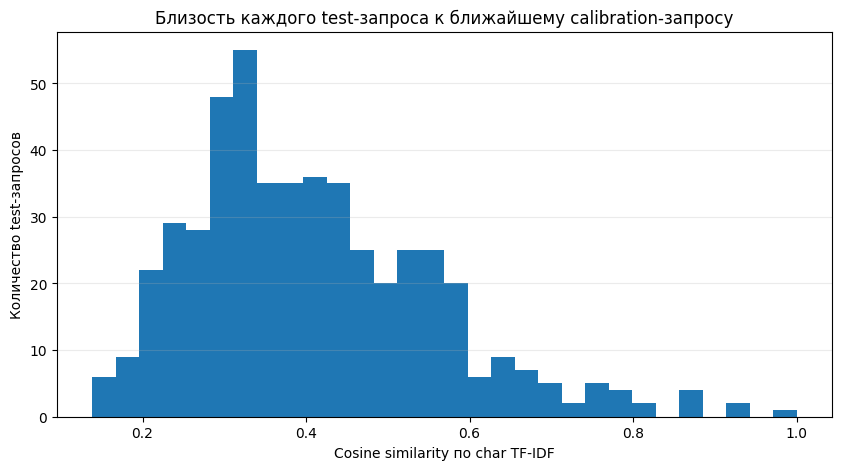

In [38]:
plt.figure(figsize=(10, 5))
plt.hist(test_similarity['nearest_similarity'], bins=30)
plt.title('Близость каждого test-запроса к ближайшему calibration-запросу')
plt.xlabel('Cosine similarity по char TF-IDF')
plt.ylabel('Количество test-запросов')
plt.grid(axis='y', alpha=0.25)
plt.show()

In [39]:
print('Самые похожие пары test → calibration:')
display(
    test_similarity.sort_values('nearest_similarity', ascending=False)[
        ['query_id', 'query_text', 'nearest_similarity', 'nearest_cal_query_id', 'nearest_cal_query', 'nearest_ground_truth']
    ].head(20)
)

Самые похожие пары test → calibration:


,query_id,query_text,nearest_similarity,nearest_cal_query_id,nearest_cal_query,nearest_ground_truth
89,90,когда мне вернут деньги за возврат,1.000000,158,Когда мне вернут деньги за возврат,2646 2865 4219
375,376,Когда вернутся деньги за возврат заказа,0.928224,64,Когда вернутся деньги за возврат,4219
349,350,когда вернуться деньги за возврат??,0.923161,364,Когда вернуться деньги за возврат товара,4219
135,136,почему не возвращаются деньги за возврат,0.864757,286,Не возвращаются деньги за заказ,4219
220,221,Не могу оплатить заказ. Пишет что-то пошло не так,0.863772,12,не могу оплатить покупку пишет что то пошло не так,3565 4389
73,74,Когда вернут деньги за возврат товара,0.861088,158,Когда мне вернут деньги за возврат,2646 2865 4219
460,461,Здравствуйте. А почему я не могу использовать при доставке накопленные бонусы?(,0.859750,72,Почему я не могу использовать накопленные бонусы для оплаты доставки?,4219
103,104,"Здравствуйте, вернул заказ ,а деньги не пришли",0.819486,103,"здравствуйте !сделал заказ,вернул его,но деньги не пришли",4219 4384
203,204,Как отправить товар авито доставкой,0.799558,91,Здравствуйте как отправить авито доставкой??,1909
427,428,подскажите как пользоваться авито доставкой?,0.797813,466,Здравствуйте как пользоваться Авито доставкой,4234


In [40]:
print('Наименее похожие test-запросы — возможные новые или сложные сценарии:')
display(
    test_similarity.sort_values('nearest_similarity', ascending=True)[
        ['query_id', 'query_text', 'nearest_similarity', 'nearest_cal_query_id', 'nearest_cal_query']
    ].head(20)
)

Наименее похожие test-запросы — возможные новые или сложные сценарии:


,query_id,query_text,nearest_similarity,nearest_cal_query_id,nearest_cal_query
189,190,Где обещаный тариф за сделку?,0.138327,265,Здравствуйте! Как вернуть заказ седланный 5пост № <ID> от <DATE>. Продавец оказался не порядочным и положил вместо обещанных вещей какой...
53,54,"вопрос про акцию от авито подработка , вознаграждение за друга",0.146152,96,Здравствуйте почему у меня авито доставка стоит в 2 раза дороже чем у моего друга
433,434,Нет для заказа пункта пятерочка,0.152673,252,"У меня большой заказ, покупатель заказал доставку через пункт выдачи авито, за упаковку мне нужно платить или нет?"
345,346,Сроки проведения хватамба,0.157685,371,Как увеличить срок отправления заказа
31,32,"Здравствуйте, я потерял свой прошлой аккаунт, создал новый, но теперь у меня отсутствует возможность оплачивать частями через сервис Пла...",0.161024,328,"Здравствуйте, бонусы на аккаунте есть, а списать не дает"
341,342,Какой налог на продажу новой одежды как магазин,0.166670,66,Я не могу заказать одежду с оплатой при получении
321,322,"Здравствуйте! Что делать, если ячейка постомата с посылкой оказалось пустой?",0.169675,196,Здравствуйте! Если отправить посылку СДЭКом можно ли оплатить наличными?
361,362,"Еще одна вещь доставлена, жду деньги от продажи",0.179967,175,"Не приходит оплата за продажи, после перехода на тариф с комиссией за продажу не пришла не одна выплата, реквизиты в профиле указанны!"
223,224,Мы зааазывали запчасть к автомобилю В сдеке сверили она нам не подходит и отказались прямо в центре выдачи Как вернуть теперь деньги?,0.181615,277,Продавец отказал в отправке. Как мне вернуть деньги ?
247,248,"Добрый день! снова ввожу офис в жк яратам в поисковике, не выходит мое объявление. с чем это связано?",0.181992,94,"Здравствуйте, почему то покупатель не может оформить заказ доставкой через почту, с чем это может быть связано? Как отправить через почт..."


### Интерпретация

Часть test-запросов имеет очень близкие аналоги в calibration. Это обосновывает supervised query-to-query retrieval: ближайшие размеченные запросы могут голосовать за свои `article_id`.

Однако низкий хвост similarity показывает, что чистый kNN недостаточен. Его нужно объединять с поиском непосредственно по корпусу статей.

## Диагностические retrieval-baseline

Цель — проверить, какие представления документов действительно содержат полезный сигнал.

In [41]:
def average_precision_at_k(relevant: set[int], predicted: list[int], k: int = 10) -> float:
    if not relevant:
        return 0.0
    hits = 0
    score = 0.0
    for rank, article_id in enumerate(predicted[:k], start=1):
        if article_id in relevant:
            hits += 1
            score += hits / rank
    return score / min(len(relevant), k)


def map_at_k(y_true: list[set[int]], rankings: list[list[int]], k: int = 10) -> float:
    return float(np.mean([
        average_precision_at_k(relevant, ranking, k)
        for relevant, ranking in zip(y_true, rankings)
    ]))


def rank_documents(query_matrix, document_matrix, article_ids, top_k=10):
    scores = linear_kernel(query_matrix, document_matrix)
    rankings = []
    article_ids = np.asarray(article_ids)
    for row in scores:
        top_idx = np.argpartition(-row, min(top_k, len(row)) - 1)[:top_k]
        top_idx = top_idx[np.argsort(-row[top_idx])]
        rankings.append(article_ids[top_idx].astype(int).tolist())
    return rankings

y_true = [set(ids) for ids in cal_eda['relevant_ids']]

In [42]:

benchmark_rows = []

# 1. Только заголовки, char TF-IDF
vectorizer = TfidfVectorizer(
    analyzer='char_wb', ngram_range=(3, 5), min_df=1,
    max_features=60_000, sublinear_tf=True, dtype=np.float32
)
doc_matrix = vectorizer.fit_transform(articles_eda['normalized_title'])
query_matrix = vectorizer.transform(cal_eda['normalized_query'])
rankings = rank_documents(query_matrix, doc_matrix, articles_eda['article_id'])
benchmark_rows.append({'representation': 'title — char TF-IDF', 'MAP@10': map_at_k(y_true, rankings)})

del doc_matrix, query_matrix, vectorizer

# 2. Заголовок + полный текст, word TF-IDF
# Для диагностики ограничиваем каждый документ 30 000 символами: этого достаточно,
# чтобы сравнить представления и не раздувать память на единичных HTML-выбросах.
full_docs_truncated = (
    articles_eda['normalized_title'] + ' ' +
    articles_eda['normalized_title'] + ' ' +
    articles_eda['normalized_body'].str.slice(0, 30_000)
)
vectorizer = TfidfVectorizer(
    analyzer='word', ngram_range=(1, 2), min_df=1,
    max_features=80_000, sublinear_tf=True, dtype=np.float32
)
doc_matrix = vectorizer.fit_transform(full_docs_truncated)
query_matrix = vectorizer.transform(cal_eda['normalized_query'])
rankings = rank_documents(query_matrix, doc_matrix, articles_eda['article_id'])
benchmark_rows.append({'representation': 'title + body — word TF-IDF', 'MAP@10': map_at_k(y_true, rankings)})

del doc_matrix, query_matrix, vectorizer

# 3. Заголовок + ограниченный текст, char TF-IDF
# Char-признаки существенно тяжелее word-признаков, поэтому берём первые 12 000 символов.
char_docs_truncated = (
    articles_eda['normalized_title'] + ' ' +
    articles_eda['normalized_title'] + ' ' +
    articles_eda['normalized_body'].str.slice(0, 12_000)
)
vectorizer = TfidfVectorizer(
    analyzer='char_wb', ngram_range=(3, 5), min_df=2,
    max_features=45_000, sublinear_tf=True, dtype=np.float32
)
doc_matrix = vectorizer.fit_transform(char_docs_truncated)
query_matrix = vectorizer.transform(cal_eda['normalized_query'])
rankings = rank_documents(query_matrix, doc_matrix, articles_eda['article_id'])
benchmark_rows.append({'representation': 'title + body — char TF-IDF', 'MAP@10': map_at_k(y_true, rankings)})

del doc_matrix, query_matrix, vectorizer

retrieval_benchmark = pd.DataFrame(benchmark_rows).sort_values('MAP@10', ascending=False)
display(retrieval_benchmark)


,representation,MAP@10
2,title + body — char TF-IDF,0.211464
1,title + body — word TF-IDF,0.197693
0,title — char TF-IDF,0.154102


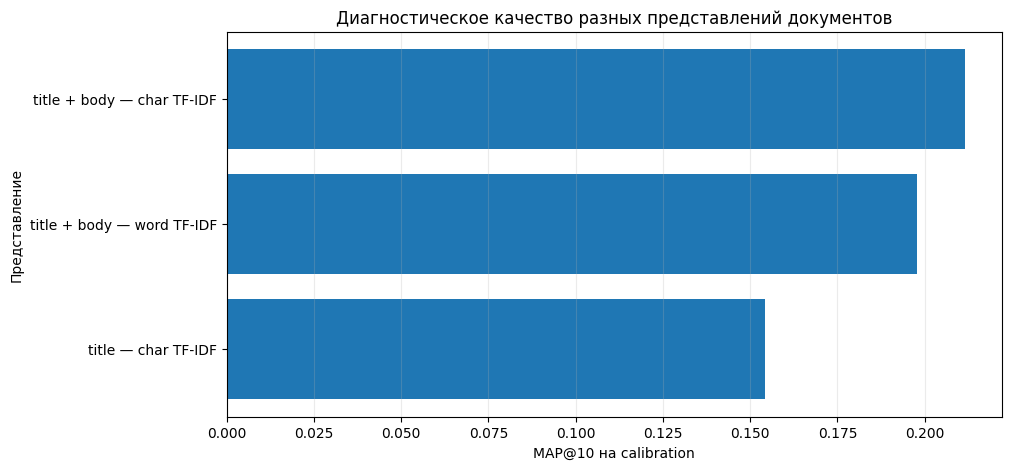

In [43]:
plot_benchmark = retrieval_benchmark.sort_values('MAP@10')
plt.figure(figsize=(10, 5))
plt.barh(plot_benchmark['representation'], plot_benchmark['MAP@10'])
plt.title('Диагностическое качество разных представлений документов')
plt.xlabel('MAP@10 на calibration')
plt.ylabel('Представление')
plt.grid(axis='x', alpha=0.25)
plt.show()

### Интерпретация

Поиск только по заголовкам существенно слабее поиска по содержанию статьи.  
Символьное представление полезно из-за опечаток и вариативности формулировок, а словесные n-граммы лучше фиксируют устойчивые смысловые фразы. Поэтому разумный baseline должен объединять несколько retrieval-сигналов.